In [7]:
import importlib
import setup_and_solve
importlib.reload(setup_and_solve)
from setup_and_solve import *

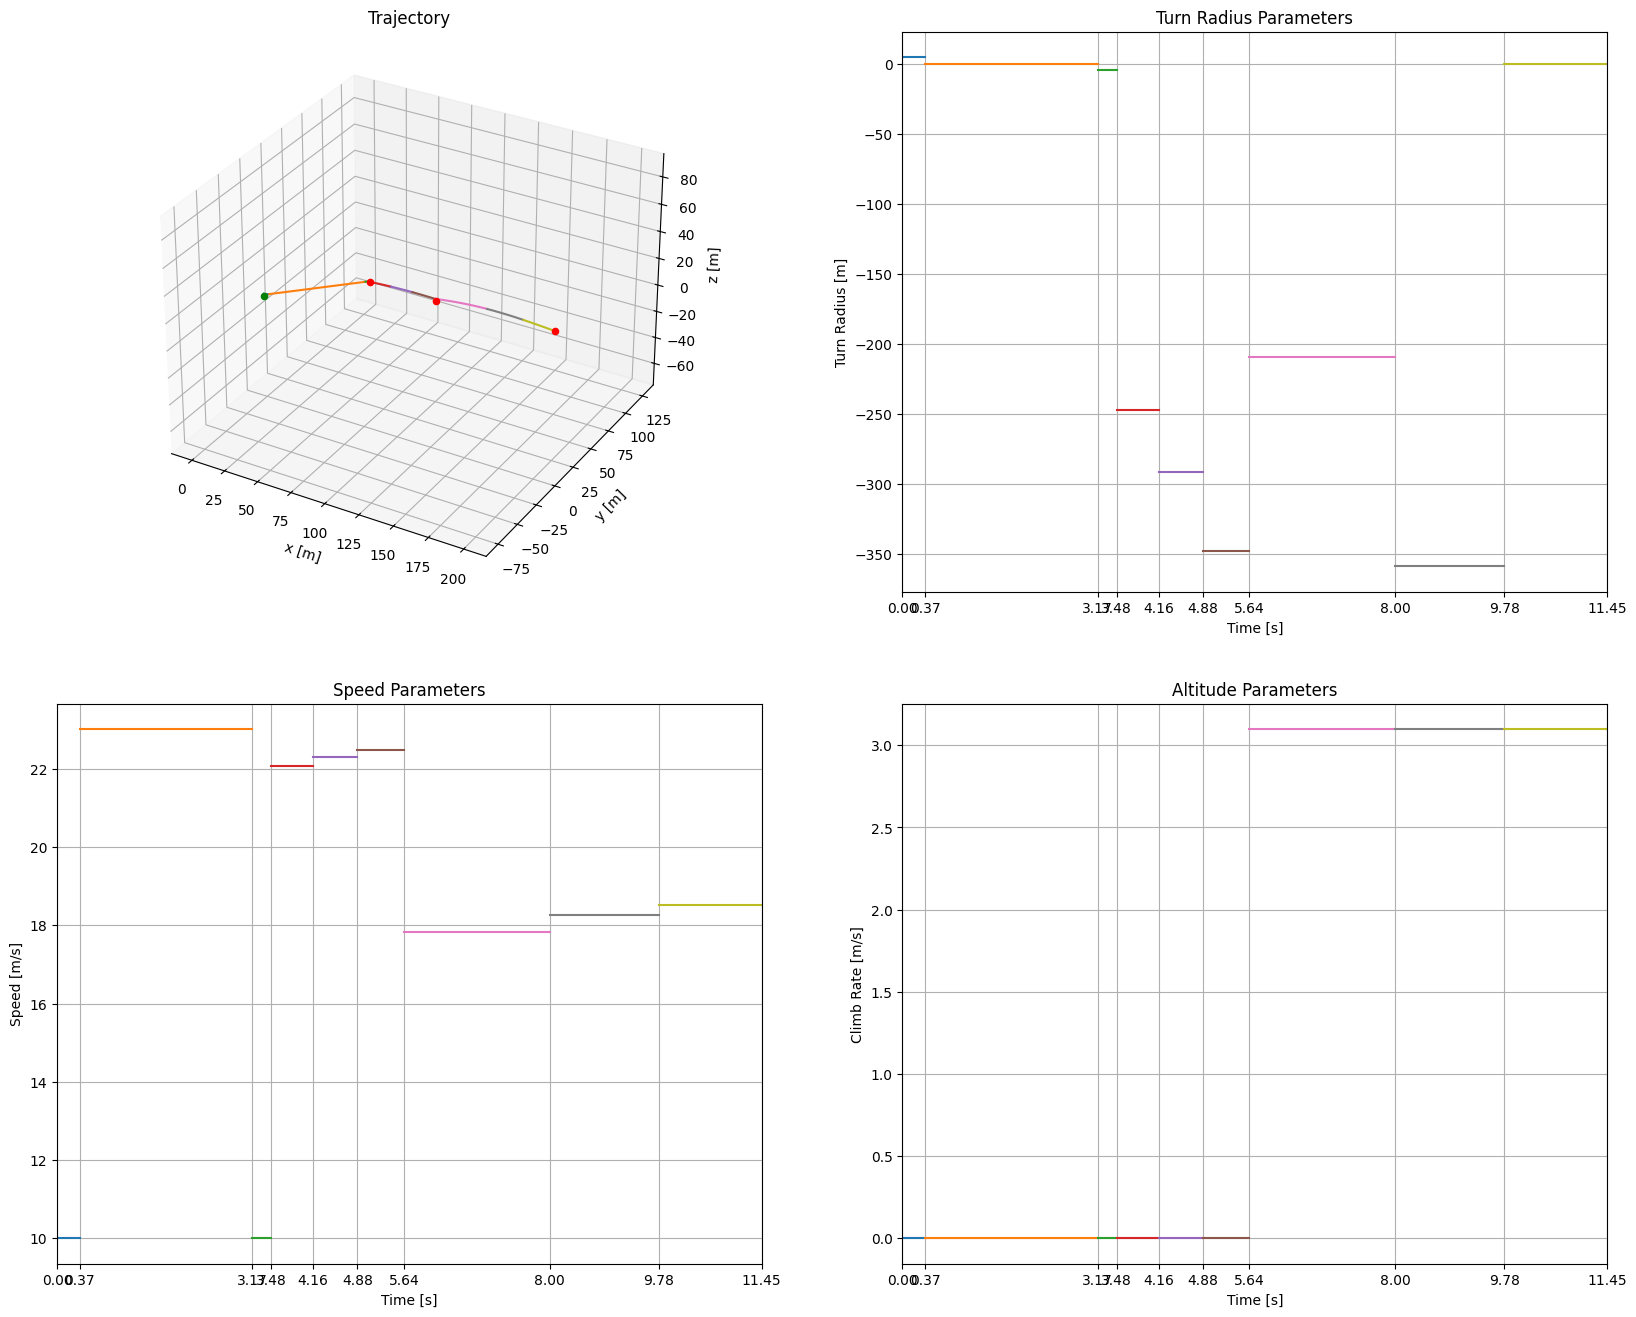

In [8]:
# First, define the start constraint.
start = StartConstraint(0, 0, 0, 0)

# Next, define the constraints. In this example, there are 2\3 constraints. The code below defines the default values of each object manually, only the spatial position arguments are required
constraints = [
    Constraint(50, 50, 0, phi_deg=0, directional=False, tolerance=1),
    Constraint(100, 50, 0, phi_deg=0, directional=False, tolerance=1),
    Constraint(200, 25, 20, phi_deg=0, directional=False, tolerance=1)
]

# With the start constraint and the trajectory constraints, define the full Trajectory object. The number of phases per constraint is 3 by default and doesn't need to be specified.
traj = Trajectory(start, constraints, phases_per_constraint=3)

# Define the Ardupilot parameters and the optimizer parameters. The code below defines the default values of each object manually, the calls ArdupilotParamenters() and OptimizerParameters() would have returned the same thing.
ap = ArdupilotParameters(
    V_max = 30,
    V_min = 10,
    V_cruise = 22,
    max_climb = 5,
    max_desc = 5,
    roll_limit = 65,
    roll_min = 5,
)
optim_params = OptimizerParameters(
    time_weight = 1,
    turn_weight = 1,
    speed_weight = 1,
    climb_weight = 1,
    segments = 9,
    points = 6,
    tol = 1e-6
)

# Crete the optimizer object.
example = Optimizer(traj, ap, optim_params)

# The following 4 steps are required to build a full Optimizer object. Calling a later function without calling the previous ones will automatically run the previous ones. However, breaking them out like this allows for reducing the run time of the slow steps, which can lead to overall performace improvements. Before running all functions, some attributes of the Optimizer object may be None.
example.setup()
example.solve()
example.extract()
example.plot()

# View the solution
example.fig